# UK Airport Passenger Demand: Exploratory Analysis

## Purpose

This notebook explores UK airport passenger demand between January 2015 and December 2025 using the cleaned monthly dataset produced by Notebook 01.

## Objectives

- examine the structure and quality of the cleaned dataset;
- compare passenger volumes across airports;
- analyse annual and monthly demand trends;
- identify seasonal patterns;
- measure the disruption caused by COVID-19;
- compare subsequent recovery across major airports;
- prepare suitable time series for forecasting.

## 1. Setup and load the cleaned passenger data

The cleaned UK airport passenger dataset created by Notebook 01 is loaded using a project-relative path.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

current_folder = Path.cwd()

if (current_folder / "data").exists():
    project_root = current_folder
elif (current_folder.parent / "data").exists():
    project_root = current_folder.parent
else:
    raise FileNotFoundError(
        "The project data folder could not be located."
    )

data_path = (
    project_root
    / "data"
    / "interim"
    / "caa_monthly_airport_passengers_2015_2025.csv"
)

passengers = pd.read_csv(
    data_path,
    parse_dates=["period_date"],
)

print(
    "Data file: "
    f"{data_path.relative_to(project_root)}"
)
print(f"Rows: {len(passengers):,}")
print(f"Columns: {passengers.shape[1]}")
print(
    "Date range: "
    f"{passengers['period_date'].min():%B %Y}"
    " to "
    f"{passengers['period_date'].max():%B %Y}"
)
print(
    "Unique airports: "
    f"{passengers['airport_name'].nunique()}"
)

display(passengers.head())

Data file: data/interim/caa_monthly_airport_passengers_2015_2025.csv
Rows: 6,230
Columns: 8
Date range: January 2015 to December 2025
Unique airports: 54


,period_date,airport_group,airport_name,total_passengers,terminal_passengers,transit_passengers,source_file,complete_history
0,2015-01-01,Other UK Airports,ABERDEEN,249165,249165,0,table09_201501.csv,True
1,2015-02-01,Other UK Airports,ABERDEEN,250294,250294,0,table09_201502.csv,True
2,2015-03-01,Other UK Airports,ABERDEEN,281553,281553,0,table09_201503.csv,True
3,2015-04-01,Other UK Airports,ABERDEEN,298203,298196,7,table09_201504.csv,True
4,2015-05-01,Other UK Airports,ABERDEEN,297671,297501,170,table09_201505.csv,True


## 2. Validate the analysis dataset

This section checks data types, missing values, duplicate airport-month records, negative passenger counts and whether total passengers reconcile to terminal plus transit passengers.

In [2]:
print("Data types:")
display(
    passengers.dtypes
    .rename("data_type")
    .to_frame()
)

print("\nMissing values:")
display(
    passengers.isna()
    .sum()
    .rename("missing")
    .to_frame()
)

duplicate_count = passengers.duplicated(
    subset=["airport_name", "period_date"]
).sum()

passenger_columns = [
    "total_passengers",
    "terminal_passengers",
    "transit_passengers",
]

negative_count = (
    passengers[passenger_columns] < 0
).sum().sum()

passengers["reconciliation_difference"] = (
    passengers["total_passengers"]
    - passengers["terminal_passengers"]
    - passengers["transit_passengers"]
)

non_reconciling_records = (
    passengers["reconciliation_difference"] != 0
).sum()

print(
    "\nDuplicate airport-month records: "
    f"{duplicate_count}"
)
print(
    "Negative passenger values: "
    f"{negative_count}"
)
print(
    "Records where total does not reconcile: "
    f"{non_reconciling_records}"
)

if non_reconciling_records > 0:
    display(
        passengers.loc[
            passengers[
                "reconciliation_difference"
            ] != 0,
            [
                "period_date",
                "airport_name",
                "total_passengers",
                "terminal_passengers",
                "transit_passengers",
                "reconciliation_difference",
            ],
        ].head(10)
    )

Data types:


,data_type
period_date,datetime64[us]
airport_group,str
airport_name,str
total_passengers,int64
terminal_passengers,int64
transit_passengers,int64
source_file,str
complete_history,bool



Missing values:


,missing
period_date,0
airport_group,0
airport_name,0
total_passengers,0
terminal_passengers,0
transit_passengers,0
source_file,0
complete_history,0



Duplicate airport-month records: 0
Negative passenger values: 0
Records where total does not reconcile: 0


## 3. Create calendar features

Year, month and quarter variables are derived from the reporting date. These will support annual comparisons, monthly seasonality analysis and time-series visualisation.

In [3]:
passengers["year"] = (
    passengers["period_date"].dt.year
)

passengers["month_number"] = (
    passengers["period_date"].dt.month
)

passengers["month_name"] = (
    passengers["period_date"].dt.month_name()
)

passengers["quarter"] = (
    passengers["period_date"]
    .dt.to_period("Q")
    .astype(str)
)

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

passengers["month_name"] = pd.Categorical(
    passengers["month_name"],
    categories=month_order,
    ordered=True,
)

print(
    passengers[
        [
            "period_date",
            "year",
            "month_number",
            "month_name",
            "quarter",
        ]
    ]
    .drop_duplicates()
    .sort_values("period_date")
    .head(15)
    .to_string(index=False)
)

period_date  year  month_number month_name quarter
 2015-01-01  2015             1    January  2015Q1
 2015-02-01  2015             2   February  2015Q1
 2015-03-01  2015             3      March  2015Q1
 2015-04-01  2015             4      April  2015Q2
 2015-05-01  2015             5        May  2015Q2
 2015-06-01  2015             6       June  2015Q2
 2015-07-01  2015             7       July  2015Q3
 2015-08-01  2015             8     August  2015Q3
 2015-09-01  2015             9  September  2015Q3
 2015-10-01  2015            10    October  2015Q4
 2015-11-01  2015            11   November  2015Q4
 2015-12-01  2015            12   December  2015Q4
 2016-01-01  2016             1    January  2016Q1
 2016-02-01  2016             2   February  2016Q1
 2016-03-01  2016             3      March  2016Q1


## 4. Analyse annual UK airport passenger demand

Monthly terminal-passenger records are aggregated across all included UK airports. Annual growth rates and comparisons with the 2019 pre-pandemic baseline are calculated.

In [4]:
annual_demand = (
    passengers.groupby(
        "year",
        as_index=False,
    )["terminal_passengers"]
    .sum()
    .rename(
        columns={
            "terminal_passengers":
                "annual_terminal_passengers"
        }
    )
)

annual_demand["passengers_millions"] = (
    annual_demand[
        "annual_terminal_passengers"
    ]
    / 1_000_000
)

annual_demand["year_on_year_change_pct"] = (
    annual_demand[
        "annual_terminal_passengers"
    ]
    .pct_change()
    .mul(100)
)

passengers_2019 = annual_demand.loc[
    annual_demand["year"] == 2019,
    "annual_terminal_passengers",
].iloc[0]

annual_demand["change_vs_2019_pct"] = (
    (
        annual_demand[
            "annual_terminal_passengers"
        ]
        / passengers_2019
    )
    .sub(1)
    .mul(100)
)

annual_display = annual_demand[
    [
        "year",
        "annual_terminal_passengers",
        "passengers_millions",
        "year_on_year_change_pct",
        "change_vs_2019_pct",
    ]
].copy()

annual_display[
    [
        "passengers_millions",
        "year_on_year_change_pct",
        "change_vs_2019_pct",
    ]
] = annual_display[
    [
        "passengers_millions",
        "year_on_year_change_pct",
        "change_vs_2019_pct",
    ]
].round(1)

display(annual_display)

,year,annual_terminal_passengers,passengers_millions,year_on_year_change_pct,change_vs_2019_pct
0,2015,251466475,251.5,NaN,-15.3
1,2016,266430321,266.4,6.0,-10.2
2,2017,284570301,284.6,6.8,-4.1
3,2018,291899598,291.9,2.6,-1.6
4,2019,296795094,296.8,1.7,0.0
5,2020,73751894,73.8,-75.2,-75.2
6,2021,64383158,64.4,-12.7,-78.3
7,2022,221778601,221.8,244.5,-25.3
8,2023,272791940,272.8,23.0,-8.1
9,2024,292469208,292.5,7.2,-1.5


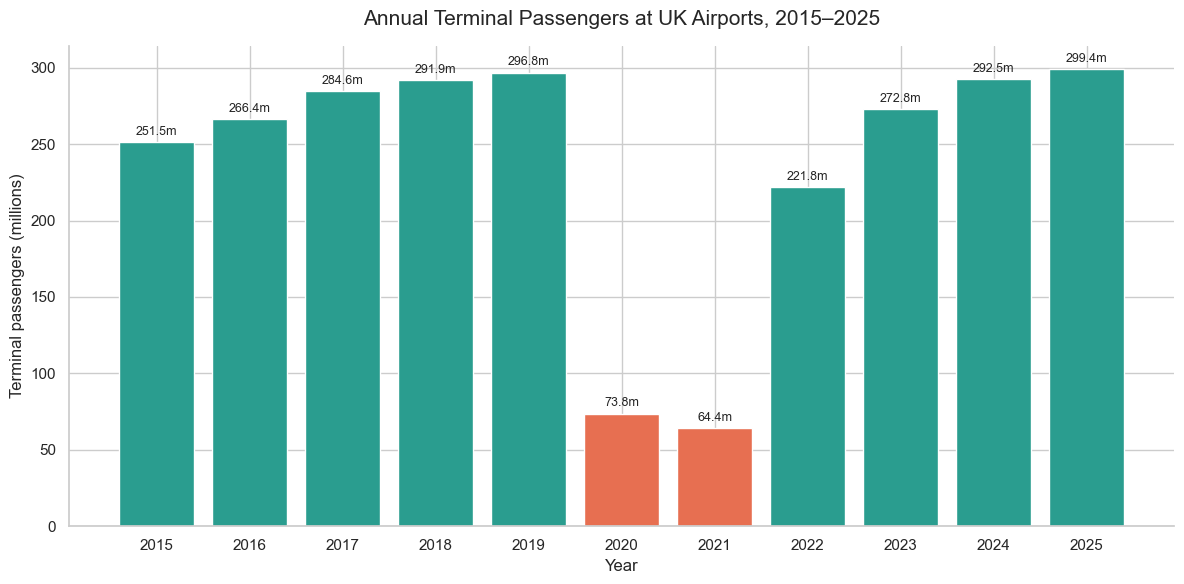

In [5]:
bar_colours = [
    "#E76F51" if year in [2020, 2021]
    else "#2A9D8F"
    for year in annual_demand["year"]
]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    annual_demand["year"],
    annual_demand["passengers_millions"],
    color=bar_colours,
)

ax.set_title(
    "Annual Terminal Passengers at UK Airports, 2015–2025",
    fontsize=15,
    pad=15,
)
ax.set_xlabel("Year")
ax.set_ylabel("Terminal passengers (millions)")
ax.set_xticks(annual_demand["year"])

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}m"
        for value in annual_demand[
            "passengers_millions"
        ]
    ],
    padding=3,
    fontsize=9,
)

sns.despine()
plt.tight_layout()
plt.show()

### Annual-demand findings

UK airport terminal-passenger demand increased from 251.5 million in 2015 to 296.8 million in 2019.

The COVID-19 disruption reduced demand by 75.2% in 2020. Passenger numbers fell further in 2021 because restrictions affected almost the entire year, whereas the opening months of 2020 still experienced relatively normal travel.

Demand recovered strongly from 2022 onwards. By 2024, passenger numbers were only 1.5% below the 2019 baseline. In 2025, demand reached 299.4 million and exceeded the 2019 level by 0.9%.

## 5. Compare passenger demand across airports

Airports are ranked using their total terminal passengers during 2025, the latest complete calendar year.

In [6]:
airport_ranking_2025 = (
    passengers.loc[
        passengers["year"] == 2025
    ]
    .groupby(
        [
            "airport_group",
            "airport_name",
        ],
        as_index=False,
    )["terminal_passengers"]
    .sum()
    .sort_values(
        "terminal_passengers",
        ascending=False,
    )
)

airport_ranking_2025["passengers_millions"] = (
    airport_ranking_2025[
        "terminal_passengers"
    ]
    / 1_000_000
)

airport_ranking_2025["market_share_pct"] = (
    airport_ranking_2025[
        "terminal_passengers"
    ]
    / airport_ranking_2025[
        "terminal_passengers"
    ].sum()
    * 100
)

top_15_airports = (
    airport_ranking_2025
    .head(15)
    .copy()
)

display(
    top_15_airports[
        [
            "airport_name",
            "airport_group",
            "terminal_passengers",
            "passengers_millions",
            "market_share_pct",
        ]
    ].round(
        {
            "passengers_millions": 1,
            "market_share_pct": 1,
        }
    )
)

,airport_name,airport_group,terminal_passengers,passengers_millions,market_share_pct
1,HEATHROW,London Area Airports,84462273,84.5,28.2
0,GATWICK,London Area Airports,42769164,42.8,14.3
35,MANCHESTER,Other UK Airports,32061307,32.1,10.7
5,STANSTED,London Area Airports,29758490,29.8,9.9
3,LUTON,London Area Airports,17768944,17.8,5.9
21,EDINBURGH,Other UK Airports,16969189,17.0,5.7
12,BIRMINGHAM,Other UK Airports,13660382,13.7,4.6
15,BRISTOL,Other UK Airports,10832713,10.8,3.6
24,GLASGOW,Other UK Airports,8205280,8.2,2.7
9,BELFAST INTERNATIONAL,Other UK Airports,6677021,6.7,2.2


In [7]:
concentration_summary = pd.DataFrame(
    {
        "largest_airports": [
            "Top 1",
            "Top 3",
            "Top 5",
            "Top 10",
            "Top 15",
        ],
        "market_share_pct": [
            airport_ranking_2025
            .head(number)["market_share_pct"]
            .sum()
            for number in [1, 3, 5, 10, 15]
        ],
    }
)

concentration_summary[
    "market_share_pct"
] = concentration_summary[
    "market_share_pct"
].round(1)

display(concentration_summary)

,largest_airports,market_share_pct
0,Top 1,28.2
1,Top 3,53.2
2,Top 5,69.1
3,Top 10,87.9
4,Top 15,95.7


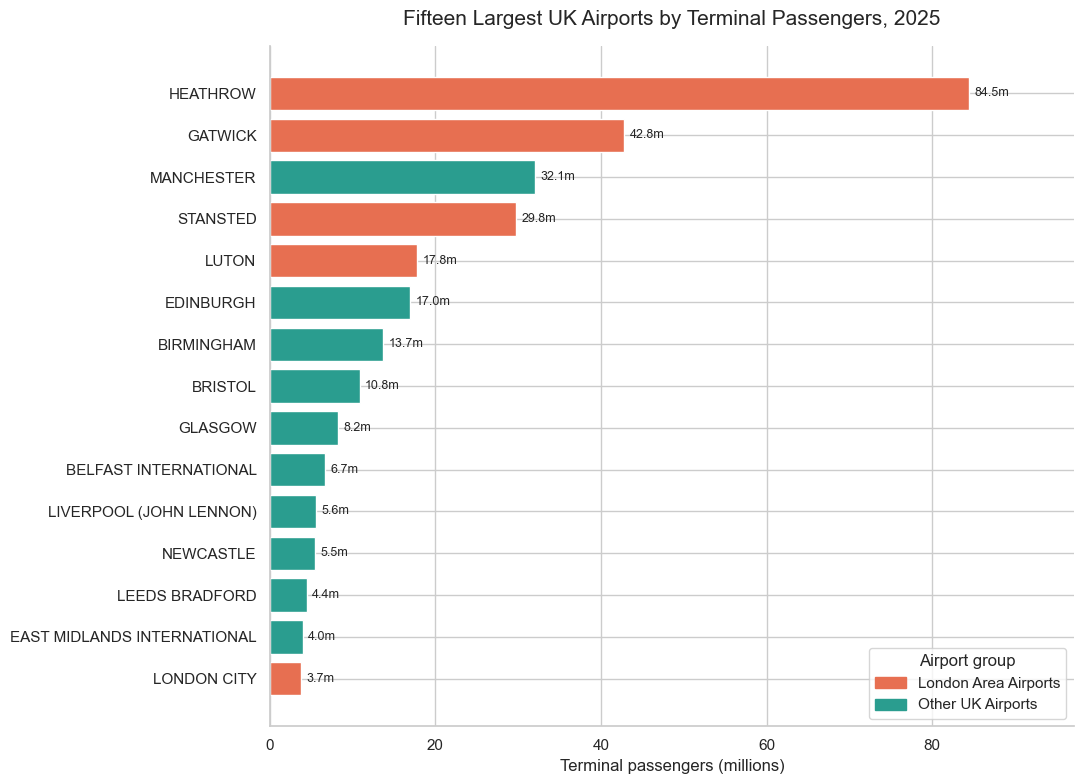

In [8]:
plot_data = (
    top_15_airports
    .sort_values(
        "passengers_millions",
        ascending=True,
    )
)

colour_map = {
    "London Area Airports": "#E76F51",
    "Other UK Airports": "#2A9D8F",
}

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    plot_data["airport_name"],
    plot_data["passengers_millions"],
    color=plot_data[
        "airport_group"
    ].map(colour_map),
)

ax.set_title(
    "Fifteen Largest UK Airports by Terminal Passengers, 2025",
    fontsize=15,
    pad=15,
)
ax.set_xlabel("Terminal passengers (millions)")
ax.set_ylabel("")

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}m"
        for value in plot_data[
            "passengers_millions"
        ]
    ],
    padding=4,
    fontsize=9,
)

from matplotlib.patches import Patch

ax.legend(
    handles=[
        Patch(
            color=colour,
            label=group,
        )
        for group, colour
        in colour_map.items()
    ],
    title="Airport group",
    loc="lower right",
)

ax.set_xlim(
    0,
    plot_data["passengers_millions"].max()
    * 1.15,
)

sns.despine()
plt.tight_layout()
plt.show()

### Airport-ranking findings

UK passenger demand is highly concentrated. Heathrow accounted for 28.2% of terminal passengers in 2025, while the three largest airports—Heathrow, Gatwick and Manchester—handled 53.2%.

The five largest airports accounted for 69.1% of demand, and the fifteen largest accounted for 95.7%. Manchester was the largest airport outside the London area.

Four London airports appeared among the five largest airports, demonstrating the importance of London to the UK aviation market.

## 6. Analyse monthly seasonality

Seasonality is measured using relatively stable years: 2015–2019 and 2023–2025. The heavily disrupted and early-recovery years 2020–2022 are excluded.

Each month is expressed as a share of its annual passenger total. A seasonal index of 100 represents an average month; values above 100 indicate above-average demand.

In [9]:
stable_years = [
    2015,
    2016,
    2017,
    2018,
    2019,
    2023,
    2024,
    2025,
]

monthly_national = (
    passengers.groupby(
        [
            "year",
            "month_number",
            "month_name",
        ],
        observed=True,
        as_index=False,
    )["terminal_passengers"]
    .sum()
)

monthly_national["annual_total"] = (
    monthly_national.groupby(
        "year"
    )["terminal_passengers"]
    .transform("sum")
)

monthly_national["monthly_share"] = (
    monthly_national["terminal_passengers"]
    / monthly_national["annual_total"]
)

seasonality = (
    monthly_national.loc[
        monthly_national["year"]
        .isin(stable_years)
    ]
    .groupby(
        [
            "month_number",
            "month_name",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        average_monthly_share=(
            "monthly_share",
            "mean",
        ),
        average_passengers=(
            "terminal_passengers",
            "mean",
        ),
    )
    .sort_values("month_number")
)

seasonality["seasonal_index"] = (
    seasonality["average_monthly_share"]
    * 12
    * 100
)

seasonality["average_passengers_millions"] = (
    seasonality["average_passengers"]
    / 1_000_000
)

display(
    seasonality[
        [
            "month_name",
            "average_passengers_millions",
            "average_monthly_share",
            "seasonal_index",
        ]
    ].round(
        {
            "average_passengers_millions": 1,
            "average_monthly_share": 3,
            "seasonal_index": 1,
        }
    )
)

,month_name,average_passengers_millions,average_monthly_share,seasonal_index
0,January,17.6,0.062,75.0
1,February,17.8,0.063,75.8
2,March,20.8,0.074,88.4
3,April,22.8,0.081,96.7
4,May,25.3,0.090,107.6
5,June,26.9,0.096,114.6
6,July,29.0,0.103,123.6
7,August,29.6,0.105,125.9
8,September,26.9,0.096,114.6
9,October,25.2,0.090,107.5


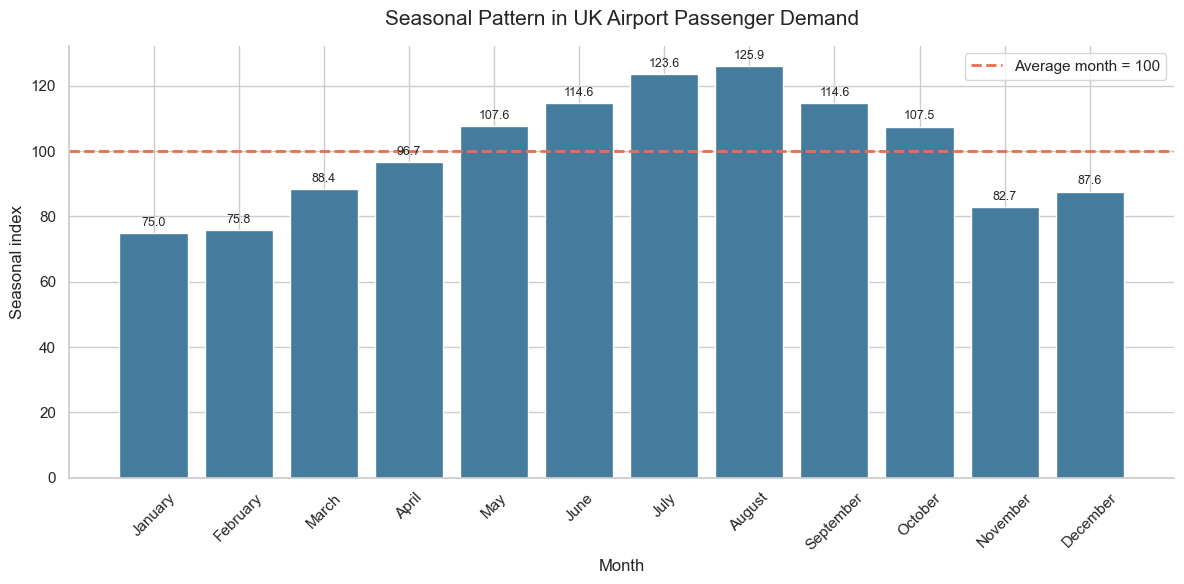

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    seasonality["month_name"].astype(str),
    seasonality["seasonal_index"],
    color="#457B9D",
)

ax.axhline(
    100,
    color="#E76F51",
    linestyle="--",
    linewidth=2,
    label="Average month = 100",
)

ax.set_title(
    "Seasonal Pattern in UK Airport Passenger Demand",
    fontsize=15,
    pad=15,
)
ax.set_xlabel("Month")
ax.set_ylabel("Seasonal index")
ax.tick_params(
    axis="x",
    rotation=45,
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}"
        for value in seasonality[
            "seasonal_index"
        ]
    ],
    padding=3,
    fontsize=9,
)

ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

### Seasonality findings

UK airport demand follows a strong seasonal pattern. Passenger volumes rise during spring, remain above average from May to October and peak in August, when demand is approximately 25.9% above an average month.

January is the quietest month, with demand approximately 25.0% below average. Demand also falls substantially during November and December.

This seasonality should be incorporated into forecasting models rather than treating every month as equivalent.

## 7. Examine the COVID-19 disruption and recovery

Monthly UK passenger demand is plotted across the full period. A 12-month rolling average is included to reveal the underlying trend while reducing seasonal variation.

Lowest-demand month: April 2020
Terminal passengers: 334,032


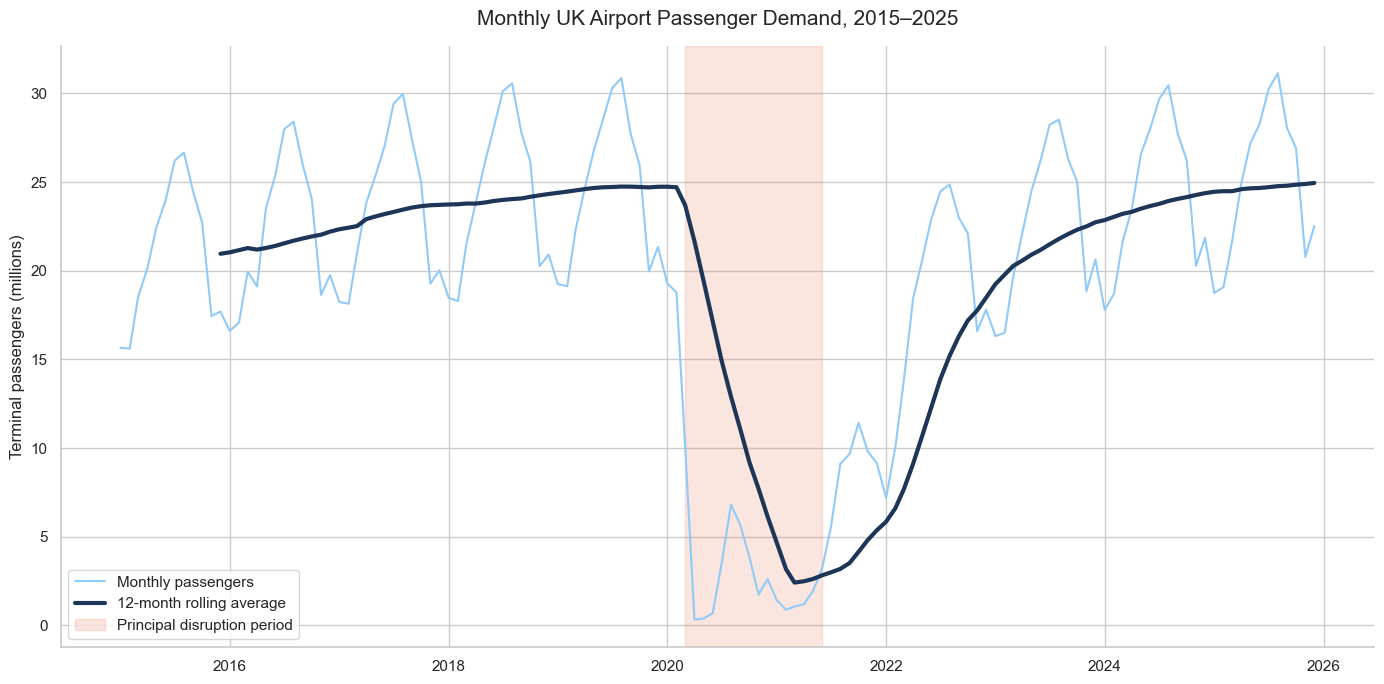

In [11]:
national_monthly = (
    passengers.groupby(
        "period_date",
        as_index=False,
    )["terminal_passengers"]
    .sum()
    .sort_values("period_date")
)

national_monthly["passengers_millions"] = (
    national_monthly["terminal_passengers"]
    / 1_000_000
)

national_monthly["rolling_12_months"] = (
    national_monthly[
        "passengers_millions"
    ]
    .rolling(
        window=12,
        min_periods=12,
    )
    .mean()
)

lowest_month = national_monthly.loc[
    national_monthly[
        "terminal_passengers"
    ].idxmin()
]

print(
    "Lowest-demand month: "
    f"{lowest_month['period_date']:%B %Y}"
)
print(
    "Terminal passengers: "
    f"{lowest_month['terminal_passengers']:,.0f}"
)

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    national_monthly["period_date"],
    national_monthly["passengers_millions"],
    color="#90CAF9",
    linewidth=1.5,
    label="Monthly passengers",
)

ax.plot(
    national_monthly["period_date"],
    national_monthly["rolling_12_months"],
    color="#1D3557",
    linewidth=3,
    label="12-month rolling average",
)

ax.axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2021-06-01"),
    color="#E76F51",
    alpha=0.18,
    label="Principal disruption period",
)

ax.set_title(
    "Monthly UK Airport Passenger Demand, 2015–2025",
    fontsize=15,
    pad=15,
)
ax.set_xlabel("")
ax.set_ylabel("Terminal passengers (millions)")
ax.legend()

sns.despine()
plt.tight_layout()
plt.show()

In [12]:
print(
    "Lowest-demand month: "
    f"{lowest_month['period_date']:%B %Y}"
)
print(
    "Terminal passengers: "
    f"{lowest_month['terminal_passengers']:,.0f}"
)

Lowest-demand month: April 2020
Terminal passengers: 334,032


### COVID-19 and recovery findings

The COVID-19 disruption caused an abrupt collapse in UK airport demand from March 2020. April 2020 was the lowest-demand month, with only 334,032 terminal passengers.

The 12-month rolling average continued falling into 2021 because travel restrictions affected a prolonged period. Recovery accelerated during 2022, and the underlying demand trend returned to approximately its pre-pandemic level during 2024.

By 2025, the rolling average and summer peak were slightly above their pre-pandemic levels, although recovery may differ between individual airports.

## 8. Compare airport recovery with 2019

Passenger demand in 2025 is compared with the 2019 pre-pandemic baseline. The comparison is restricted to airports with complete reporting histories.

In [13]:
complete_airport_data = passengers.loc[
    passengers["complete_history"]
].copy()

airport_annual = (
    complete_airport_data.groupby(
        [
            "airport_name",
            "year",
        ],
        as_index=False,
    )["terminal_passengers"]
    .sum()
)

airport_recovery = (
    airport_annual.loc[
        airport_annual["year"]
        .isin([2019, 2025])
    ]
    .pivot(
        index="airport_name",
        columns="year",
        values="terminal_passengers",
    )
    .rename(
        columns={
            2019: "passengers_2019",
            2025: "passengers_2025",
        }
    )
    .dropna()
    .reset_index()
)

airport_recovery["change_2019_to_2025"] = (
    airport_recovery["passengers_2025"]
    - airport_recovery["passengers_2019"]
)

airport_recovery["change_pct"] = (
    airport_recovery["change_2019_to_2025"]
    / airport_recovery["passengers_2019"]
    * 100
)

major_airport_recovery = (
    airport_recovery.sort_values(
        "passengers_2025",
        ascending=False,
    )
    .head(15)
    .copy()
)

major_airport_recovery[
    "passengers_2019_millions"
] = (
    major_airport_recovery["passengers_2019"]
    / 1_000_000
)

major_airport_recovery[
    "passengers_2025_millions"
] = (
    major_airport_recovery["passengers_2025"]
    / 1_000_000
)

display(
    major_airport_recovery[
        [
            "airport_name",
            "passengers_2019_millions",
            "passengers_2025_millions",
            "change_pct",
        ]
    ].round(1)
)

year,airport_name,passengers_2019_millions,passengers_2025_millions,change_pct
17,HEATHROW,80.9,84.5,4.4
15,GATWICK,46.6,42.8,-8.2
29,MANCHESTER,29.4,32.1,9.2
35,STANSTED,28.1,29.8,5.8
28,LUTON,18.2,17.8,-2.4
13,EDINBURGH,14.7,17.0,15.2
5,BIRMINGHAM,12.6,13.7,8.0
7,BRISTOL,9.0,10.8,20.9
16,GLASGOW,8.8,8.2,-7.2
3,BELFAST INTERNATIONAL,6.3,6.7,6.3


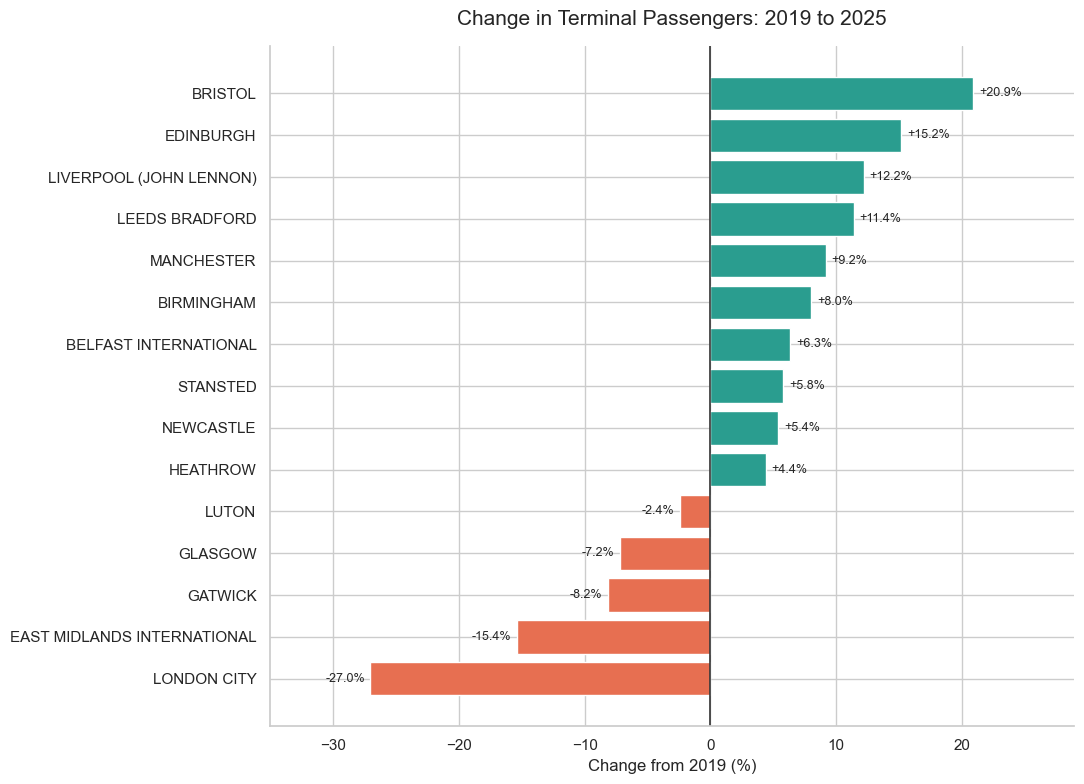

In [14]:
recovery_plot = (
    major_airport_recovery
    .sort_values("change_pct")
)

recovery_colours = [
    "#2A9D8F" if value >= 0
    else "#E76F51"
    for value in recovery_plot["change_pct"]
]

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    recovery_plot["airport_name"],
    recovery_plot["change_pct"],
    color=recovery_colours,
)

ax.axvline(
    0,
    color="#333333",
    linewidth=1.2,
)

ax.set_title(
    "Change in Terminal Passengers: 2019 to 2025",
    fontsize=15,
    pad=15,
)
ax.set_xlabel("Change from 2019 (%)")
ax.set_ylabel("")

labels = [
    f"{value:+.1f}%"
    for value in recovery_plot["change_pct"]
]

ax.bar_label(
    bars,
    labels=labels,
    padding=4,
    fontsize=9,
)

minimum_change = recovery_plot[
    "change_pct"
].min()

maximum_change = recovery_plot[
    "change_pct"
].max()

ax.set_xlim(
    minimum_change - 8,
    maximum_change + 8,
)

sns.despine()
plt.tight_layout()
plt.show()

### Airport-recovery findings

Recovery was uneven across the largest airports. Bristol recorded the strongest growth and handled 20.9% more terminal passengers in 2025 than in 2019. Edinburgh, Liverpool and Leeds Bradford also achieved double-digit growth.

Heathrow, Manchester, Stansted and Birmingham exceeded their 2019 levels. In contrast, Gatwick, Glasgow and Luton remained below their pre-pandemic totals.

London City experienced the weakest recovery among the fifteen largest airports, remaining 27.0% below its 2019 level. The national recovery therefore does not represent a uniform recovery across individual airports.

## 9. Prepare forecasting series

The national series and the ten largest airports with complete histories are selected for subsequent forecasting. Each series must contain all 132 monthly observations.

In [15]:
forecast_airport_names = (
    airport_recovery.sort_values(
        "passengers_2025",
        ascending=False,
    )
    .head(10)["airport_name"]
    .tolist()
)

airport_forecast_series = (
    passengers.loc[
        passengers["airport_name"]
        .isin(forecast_airport_names),
        [
            "period_date",
            "airport_name",
            "terminal_passengers",
        ],
    ]
    .rename(
        columns={
            "airport_name": "series_name",
        }
    )
)

national_forecast_series = (
    national_monthly[
        [
            "period_date",
            "terminal_passengers",
        ]
    ]
    .assign(series_name="UK TOTAL")
    [
        [
            "period_date",
            "series_name",
            "terminal_passengers",
        ]
    ]
)

forecasting_series = (
    pd.concat(
        [
            national_forecast_series,
            airport_forecast_series,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "series_name",
            "period_date",
        ]
    )
    .reset_index(drop=True)
)

forecasting_coverage = (
    forecasting_series.groupby(
        "series_name"
    )
    .agg(
        observations=(
            "period_date",
            "size",
        ),
        first_month=(
            "period_date",
            "min",
        ),
        last_month=(
            "period_date",
            "max",
        ),
        missing_values=(
            "terminal_passengers",
            lambda values:
                values.isna().sum(),
        ),
    )
    .reset_index()
)

display(forecasting_coverage)

,series_name,observations,first_month,last_month,missing_values
0,BELFAST INTERNATIONAL,132,2015-01-01,2025-12-01,0
1,BIRMINGHAM,132,2015-01-01,2025-12-01,0
2,BRISTOL,132,2015-01-01,2025-12-01,0
3,EDINBURGH,132,2015-01-01,2025-12-01,0
4,GATWICK,132,2015-01-01,2025-12-01,0
5,GLASGOW,132,2015-01-01,2025-12-01,0
6,HEATHROW,132,2015-01-01,2025-12-01,0
7,LUTON,132,2015-01-01,2025-12-01,0
8,MANCHESTER,132,2015-01-01,2025-12-01,0
9,STANSTED,132,2015-01-01,2025-12-01,0


### Export the forecasting dataset

The national total and ten largest complete-history airports are exported in long format for time-series modelling in Notebook 3.

In [16]:
forecast_output_path = (
    project_root
    / "data"
    / "interim"
    / "forecasting_passenger_series.csv"
)

forecasting_series.to_csv(
    forecast_output_path,
    index=False,
)

print(f"Exported: {forecast_output_path}")
print(f"Rows: {len(forecasting_series):,}")
print(f"Series: {forecasting_series['series_name'].nunique()}")
print(
    "Missing passenger values:",
    forecasting_series["terminal_passengers"].isna().sum(),
)

Exported: /Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/interim/forecasting_passenger_series.csv
Rows: 1,452
Series: 11
Missing passenger values: 0


## 10. Conclusions

- UK airport demand increased from 251.5 million terminal passengers in 2015 to 296.8 million in 2019.
- Passenger demand collapsed during the COVID-19 disruption, reaching its lowest point in April 2020 at approximately 334,000 passengers.
- UK demand recovered to 299.4 million passengers in 2025, 0.9% above the 2019 level.
- Passenger demand is concentrated among the largest airports: the five largest airports represented approximately 69.1% of the 2025 market.
- Demand is strongly seasonal. August was approximately 25.9% above an average month, while January was approximately 25.0% below average.
- Recovery differed substantially between airports. Bristol was 20.9% above its 2019 passenger level in 2025, while London City remained 27.0% below.
- A forecasting dataset containing the UK total and ten major airports was created for Notebook 3. Each series contains 132 complete monthly observations from January 2015 to December 2025.